# Expirements for the Image Sticthing App

In [1]:
import cv2 
import numpy as np
import pandas as pd
import sticth_app
import matplotlib.pyplot as plt

## Critical Stepps
1. Get All Features Into a Table

In [2]:
img_paths = sticth_app.get_image_files("/home/schmidtg/coding_projetcs/local-image-features-apps/image-stitching/datasets/example-data/flower")
orb = cv2.ORB_create()

img_id_bounds = np.array([0], dtype=np.uint32)  # indicated at which ID an image starts/end
N = 0
des = np.empty((0,32), dtype=np.uint8) # data type is crucial!
img_ids = np.empty((0))

for img_id, img_path in enumerate(img_paths): 
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    kp_new, des_new = orb.detectAndCompute(img, None)  # type: ignore
    des = np.vstack((des, des_new))
    N_new = len(des_new)
    N += N_new
    img_id_bounds = np.append(img_id_bounds, N)
    img_ids_new = np.full((N_new), img_id+1)
    img_ids = np.concatenate((img_ids, img_ids_new), axis=0)

In [3]:
# descriptor IDs from at 0 until 499, belong to Image ID 1
# descriptor IDs from at 500 until 999, belong to Image ID 2
# ...
# descriptor IDs from at 1500 until 1999, belong to Image ID 4
img_id_bounds

array([   0,  500, 1000, 1500, 2000])

In [4]:
img_ids

array([1., 1., 1., ..., 4., 4., 4.], shape=(2000,))

In [5]:
des

array([[ 57, 151,  87, ..., 142, 240, 217],
       [ 57, 241, 106, ..., 130, 110, 233],
       [ 17, 137, 194, ..., 136, 177, 136],
       ...,
       [184,  75,  74, ...,  59, 126, 138],
       [101,  32, 128, ..., 121, 122, 130],
       [ 66, 154,  42, ...,   4,  45,  95]], shape=(2000, 32), dtype=uint8)

In [6]:
matching_df = pd.DataFrame(
    {"Descriptor" : des.tolist(),
     "ImgId" : img_ids})
convert_dict ={'ImgId': np.uint8}  # dont expect more than 2^8 / 255 images
matching_df = matching_df.astype(convert_dict)
print(matching_df.dtypes)
matching_df.head()

Descriptor    object
ImgId          uint8
dtype: object


,Descriptor,ImgId
0,"[57, 151, 87, 239, 116, 158, 106, 52, 109, 73,...",1
1,"[57, 241, 106, 65, 84, 221, 235, 112, 224, 236...",1
2,"[17, 137, 194, 249, 150, 163, 104, 71, 54, 1, ...",1
3,"[204, 142, 45, 249, 184, 238, 73, 187, 182, 63...",1
4,"[157, 135, 107, 42, 146, 54, 95, 248, 112, 206...",1


In [7]:
# Define FLANN parameters and match descriptors
# from https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
FLANN_INDEX_LSH = 6
index_params= dict(algorithm = FLANN_INDEX_LSH,
                   table_number = 6, # 12
                   key_size = 12,     # 20
                   multi_probe_level = 1) #2
search_params = dict(checks=50)   # or pass empty dictionary
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des,des, k=5)

# 2nd Method, Not Working
# FLANN_INDEX_KDTREE = 0
# index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
# search_params = dict(checks=50)
# flann = cv2.FlannBasedMatcher(index_params, search_params)
# matches = flann.knnMatch(des, des, k=2)

In [8]:
# queryIdx == OG DescriptorID  trainIdx == matched DescriptorID 
matched_col = [np.array([m.trainIdx for m in M[1:]]) for M in matches]

In [9]:
matching_df['Matched_Ids'] = matched_col

In [10]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids
0,"[57, 151, 87, 239, 116, 158, 106, 52, 109, 73,...",1,"[149, 1826, 742, 1373]"
1,"[57, 241, 106, 65, 84, 221, 235, 112, 224, 236...",1,"[133, 789, 1611, 1836]"
2,"[17, 137, 194, 249, 150, 163, 104, 71, 54, 1, ...",1,"[543, 110, 653, 266]"
3,"[204, 142, 45, 249, 184, 238, 73, 187, 182, 63...",1,"[118, 75, 84, 1637]"
4,"[157, 135, 107, 42, 146, 54, 95, 248, 112, 206...",1,"[1665, 877, 1563, 1143]"


In [11]:
# convert matched descriptor ids to img ids 
def descriptor_id_to_img_id(id,bounds) -> int:
    """
    Get the associated Image ID for the given Descriptor ID, using the given bounds. 
    Returns:
        int: in range from 1 to length of bounds
    """
    return np.searchsorted(bounds, id, side='right')

def matched_ids_to_img_ids(row, bounds):
    matched_ids = row['Matched_Ids']
    img_ids = [descriptor_id_to_img_id(id, bounds) for id in matched_ids]
    return np.array(img_ids)

matching_df['Matched_ImgIds'] = matching_df.apply(matched_ids_to_img_ids, 
                                                  axis=1, 
                                                  args=(img_id_bounds,))

In [12]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[57, 151, 87, 239, 116, 158, 106, 52, 109, 73,...",1,"[149, 1826, 742, 1373]","[1, 4, 2, 3]"
1,"[57, 241, 106, 65, 84, 221, 235, 112, 224, 236...",1,"[133, 789, 1611, 1836]","[1, 2, 4, 4]"
2,"[17, 137, 194, 249, 150, 163, 104, 71, 54, 1, ...",1,"[543, 110, 653, 266]","[2, 1, 2, 1]"
3,"[204, 142, 45, 249, 184, 238, 73, 187, 182, 63...",1,"[118, 75, 84, 1637]","[1, 1, 1, 4]"
4,"[157, 135, 107, 42, 146, 54, 95, 248, 112, 206...",1,"[1665, 877, 1563, 1143]","[4, 2, 4, 3]"


In [13]:
# remove Matched Ids of descriptors that belong to the same image
def remove_invalid_matches(row) -> pd.Series:
    """
    Remnoves Ids from Matched_Ids that are the are from the same Image (ImgId)

    Args:
        row: a row from a pandas dataframe

    Returns:
        series: a series for containing the updated Matched_Ids and Matched_ImgIds, with invalid values removed.
    """
    matched_ids, img_ids, imgId = row['Matched_Ids'], row['Matched_ImgIds'], row['ImgId'] 
    indeces_to_remove = np.where(img_ids == imgId)
    # create mask to remove values
    mask = np.ones(len(matched_ids), dtype=bool)
    mask[indeces_to_remove] = False
    matched_ids = matched_ids[mask,...]
    img_ids = img_ids[mask,...]
    return pd.Series([matched_ids, img_ids])

In [14]:
matching_df[["Matched_Ids", "Matched_ImgIds"]] = matching_df.apply(remove_invalid_matches, axis=1)
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[57, 151, 87, 239, 116, 158, 106, 52, 109, 73,...",1,"[1826, 742, 1373]","[4, 2, 3]"
1,"[57, 241, 106, 65, 84, 221, 235, 112, 224, 236...",1,"[789, 1611, 1836]","[2, 4, 4]"
2,"[17, 137, 194, 249, 150, 163, 104, 71, 54, 1, ...",1,"[543, 653]","[2, 2]"
3,"[204, 142, 45, 249, 184, 238, 73, 187, 182, 63...",1,[1637],[4]
4,"[157, 135, 107, 42, 146, 54, 95, 248, 112, 206...",1,"[1665, 877, 1563, 1143]","[4, 2, 4, 3]"


In [15]:
# Get the counts of imag matches

In [16]:
img_id_stats_df = matching_df.explode('Matched_ImgIds')
result = (
    img_id_stats_df
    .groupby(['ImgId', 'Matched_ImgIds'])
    .size()
    .reset_index(name='Count')
    .rename(columns={'Matched_ImgIds': 'MatchedWith'})
)

print(result)

    ImgId  MatchedWith  Count
0       1            2    491
1       1            3    304
2       1            4    242
3       2            1    483
4       2            3    433
5       2            4    205
6       3            1    298
7       3            2    484
8       3            4    430
9       4            1    297
10      4            2    303
11      4            3    411


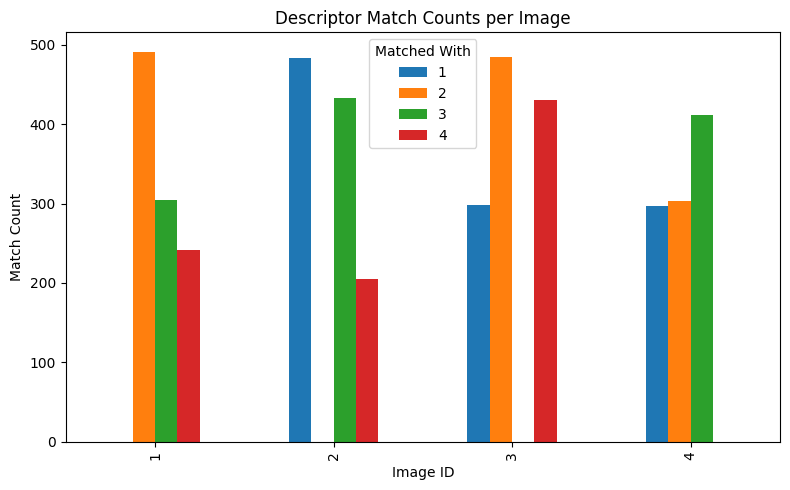

In [17]:
# Pivot the data so each "MatchedWith" becomes a column
pivot_df = result.pivot(index='ImgId', columns='MatchedWith', values='Count').fillna(0)

# Plot grouped bars
pivot_df.plot(kind='bar', figsize=(8,5))

plt.title("Descriptor Match Counts per Image")
plt.xlabel("Image ID")
plt.ylabel("Match Count")
plt.legend(title="Matched With")
plt.tight_layout()
plt.show()